<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Simulated_Laser_Scan_Path.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1089/2692280870.py:54: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('X Position ($\mu m$)')
/tmp/ipykernel_1089/2692280870.py:55: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Y Position ($\mu m$)')


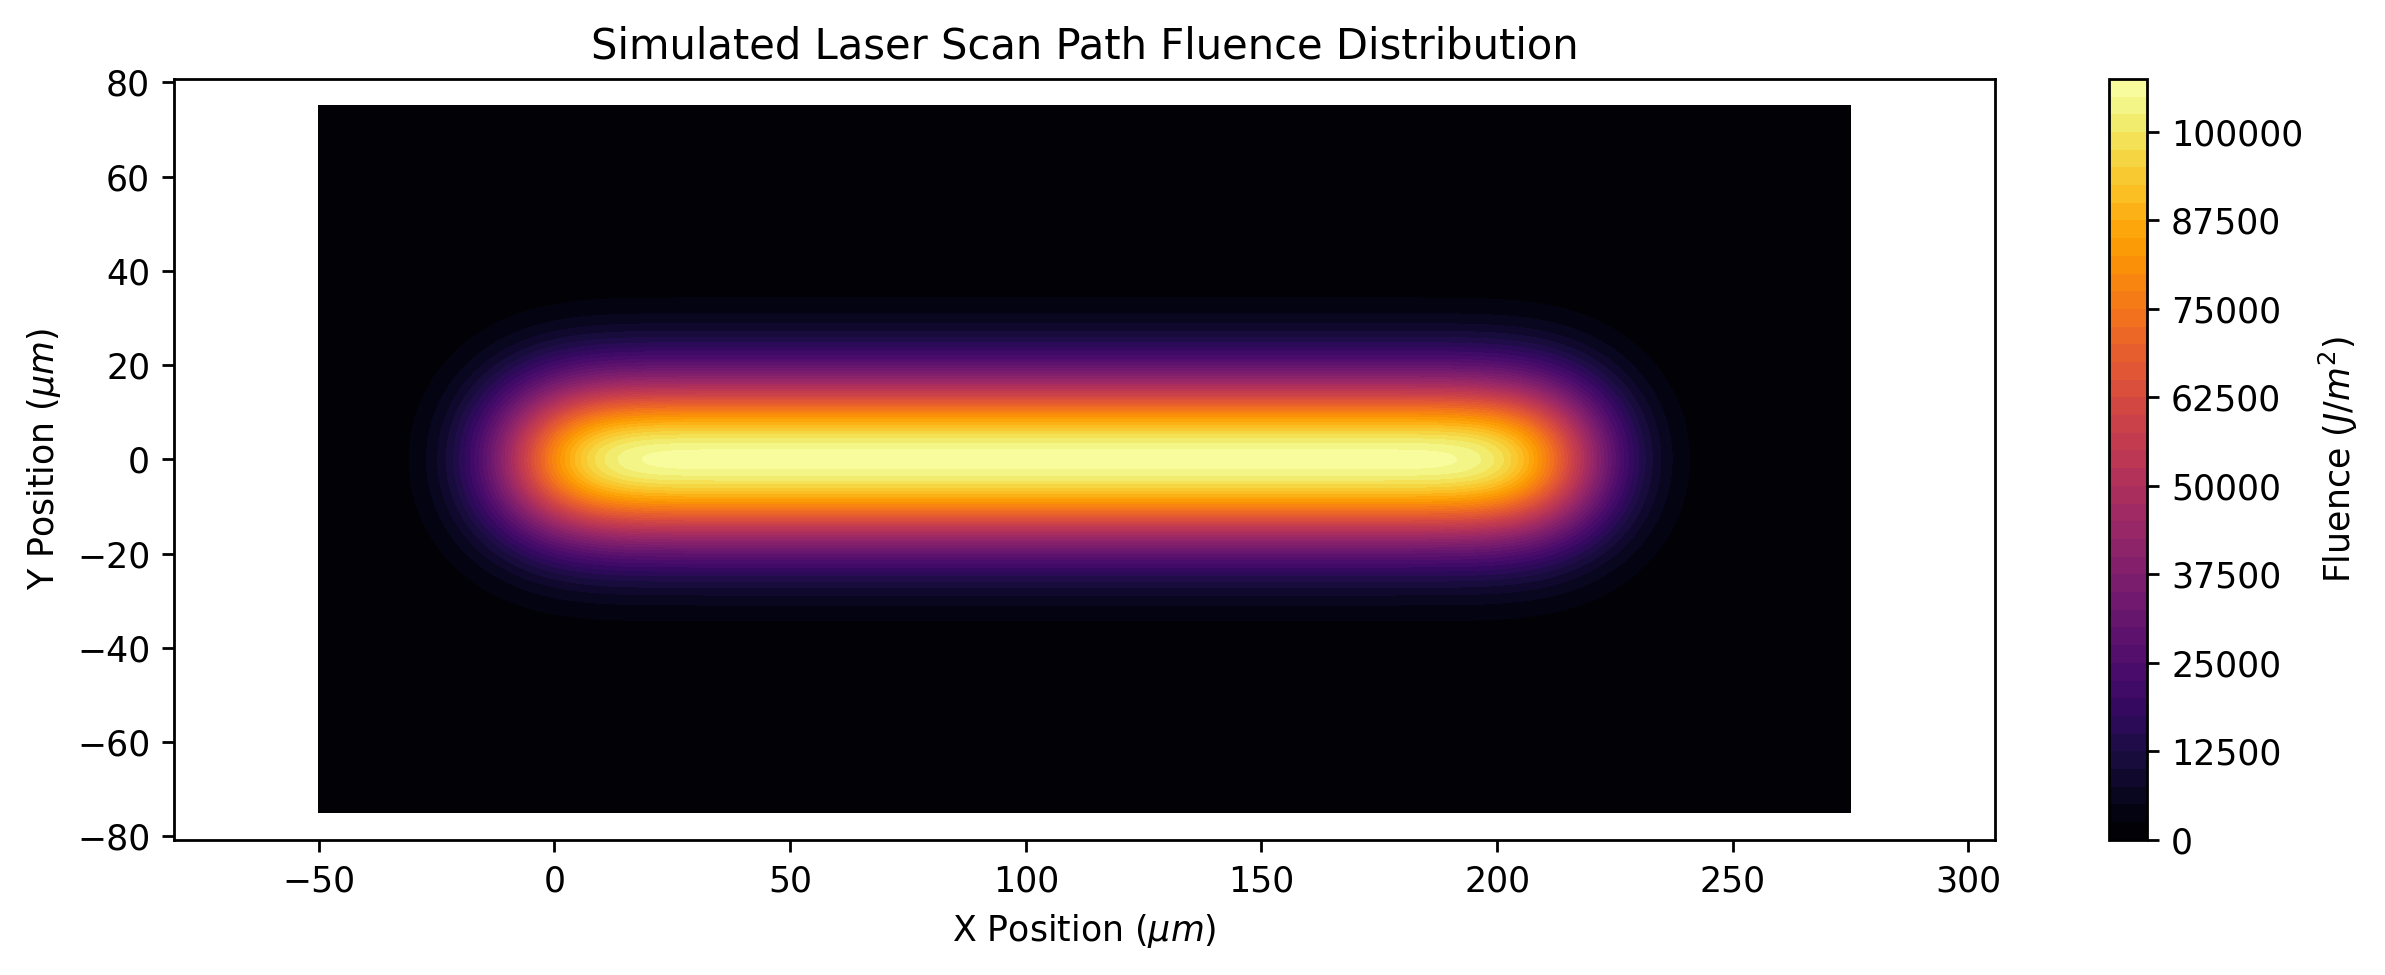

In [1]:
"""
Laser Ablation Scan Path Simulator.

This script visualizes the cumulative energy density (fluence)
deposited on a metal surface by a scanning Gaussian laser beam.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
PULSE_ENERGY = 50e-6      # Energy per pulse in Joules (J)
SPOT_RADIUS = 25e-6       # Laser beam waist (w0) in meters (m)
PULSE_COUNT = 15          # Number of pulses in the scan line
OVERLAP_RATIO = 0.7       # Percent overlap between consecutive pulses (0 to 1)
RESOLUTION = 500          # Grid resolution for the plot
# ---------------------

def gaussian_2d(x, y, x0, y0, w0, energy):
    """
    Calculate the fluence of a single Gaussian pulse.

    Parameters:
        x, y: Grid coordinates.
        x0, y0: Pulse center coordinates.
        w0: Beam waist radius.
        energy: Pulse energy.
    """
    # Peak fluence F0 = 2 * E / (pi * w0^2)
    f0 = (2 * energy) / (np.pi * w0**2)
    return f0 * np.exp(-2 * ((x - x0)**2 + (y - y0)**2) / w0**2)

def simulate_scan():
    """Execute the laser scan simulation and render the plot."""
    # Define the spatial domain based on spot size and pulse count
    spacing = 2 * SPOT_RADIUS * (1 - OVERLAP_RATIO)
    x_range = np.linspace(-2 * SPOT_RADIUS, PULSE_COUNT * spacing + 2 * SPOT_RADIUS, RESOLUTION)
    y_range = np.linspace(-3 * SPOT_RADIUS, 3 * SPOT_RADIUS, RESOLUTION)
    x_grid, y_grid = np.meshgrid(x_range, y_range)

    total_fluence = np.zeros_like(x_grid)

    # Accumulate energy from each pulse
    for i in range(PULSE_COUNT):
        x_pos = i * spacing
        total_fluence += gaussian_2d(x_grid, y_grid, x_pos, 0, SPOT_RADIUS, PULSE_ENERGY)

    # Rendering
    plt.rcParams['figure.dpi'] = 250
    plt.figure(figsize=(10, 4))
    cp = plt.contourf(x_grid * 1e6, y_grid * 1e6, total_fluence, levels=50, cmap='inferno')
    plt.colorbar(cp, label='Fluence ($J/m^2$)')
    plt.title('Simulated Laser Scan Path Fluence Distribution')
    plt.xlabel('X Position ($\mu m$)')
    plt.ylabel('Y Position ($\mu m$)')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_scan()